## turbineSiting (*geo3D*)

[**Gouda Wind Facility**](https://en.wikipedia.org/wiki/Gouda_Wind_Facility), Western Cape South Africa *--not the entire site*

In [1]:
#load the magic

%matplotlib inline
import os
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
import json
import geojson

from cjio import cityjson

import openSiting

import matplotlib.pyplot as plt

In [3]:
# With the new 0.10.x syntax:
with open('25mTerrain3DTurbines.json', 'r') as f:
    cm = cityjson.reader(f)

In [4]:
print(cm)

CityJSON version = 2.0.0
EPSG = 32734
bbox = [ 315173.947 6316285.467 58.707 318226.343 6319328.635 122.186 ]
=== CityObjects ===
|-- TINRelief (1)
|-- OtherConstruction (12)
materials = False
textures = False


In [5]:
# Extract data directly from the dictionary we built
data = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # We only want Buildings for this GDF, skipping the terrain (TINRelief)
    if obj_data['type'] == 'OtherConstruction':
        row = {'id': obj_id}
        row.update(obj_data.get('attributes', {}))
        data.append(row)

df = pd.DataFrame(data)
df.head(2)

,id,class,mastID,X,Y,lat,lon,manufacturer,model,rated_power_kw,...,cut_in_ms,rated_ms,cut_out_ms,iec_class,generator_type,gearbox_type,gearbox_stages,onshore,offshore,ground_height
0,area_of_interest,wind_turbine,15,315867.200009,6.318783e+06,-33.2632,19.0321,Acciona,AW-3000/100,3000,...,4.0,11.7,25.0,la,DFIG,spur_planetary,3,True,False,66.410004
1,area_of_interest,wind_turbine,19,315838.721774,6.318077e+06,-33.2632,19.0321,Acciona,AW-3000/100,3000,...,4.0,11.7,25.0,la,DFIG,spur_planetary,3,True,False,64.639999


In [7]:
#df = cm.to_dataframe()
#- remove the first feature: the terrain
#df = df[1:]    

#- harvest the crs
theinfo = cm.get_info()
crs = theinfo[1]

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['X'], df['Y']), 
    crs=crs[7:]
)
gdf.head(2)

,id,class,mastID,X,Y,lat,lon,manufacturer,model,rated_power_kw,...,rated_ms,cut_out_ms,iec_class,generator_type,gearbox_type,gearbox_stages,onshore,offshore,ground_height,geometry
0,area_of_interest,wind_turbine,15,315867.200009,6.318783e+06,-33.2632,19.0321,Acciona,AW-3000/100,3000,...,11.7,25.0,la,DFIG,spur_planetary,3,True,False,66.410004,POINT (315867.200 6318783.140)
1,area_of_interest,wind_turbine,19,315838.721774,6.318077e+06,-33.2632,19.0321,Acciona,AW-3000/100,3000,...,11.7,25.0,la,DFIG,spur_planetary,3,True,False,64.639999,POINT (315838.722 6318076.840)


In [8]:
#gdf.head(2)
bbox = theinfo[2]
extent = [float(bbox[9:18]), float(bbox[20:30]), float(bbox[39:48]), float(bbox[50:60])]

extent
#[315173.9466398532, 6316285.467382115, 318226.3425625299, 6319328.635225126]

[315173.94, 6316285.46, 318226.34, 6319328.63]

In [9]:
Su_inlet = 6.9      # m/s
Su_deg = 210        # @ 600 hour/year | https://www.meteoblue.com/en/weather/historyclimate/climatemodelled/gouda_south-africa_3367553

In [11]:
#- harvest the data
#start = time.time()

summer_path = './result/openfoam/gouda'

summerFull, center_x_utm, center_y_utm  = openSiting.reconstruct_openfoam_results(summer_path, gdf, Su_deg, extent, radius=3000)
summer100m = summerFull[(summerFull['Z'] >= 70) & (summerFull['Z'] <= 130)].copy()

#end = time.time()
#print('runtime:', str(timedelta(seconds=(end - start))))

summer100m.head(5)

,X,Y,Z,U,V,u_mag
2240,319139.600416,6.316167e+06,75.350500,2.055046,3.427506,3.996375
2241,319235.707966,6.316334e+06,75.351675,2.041387,3.412506,3.976488
2242,319331.815716,6.316500e+06,75.352775,2.026569,3.398659,3.957002
2243,318737.401781,6.315734e+06,75.342763,2.097334,3.480190,4.063315
2244,318833.509344,6.315900e+06,75.342763,2.086330,3.459570,4.039974


In [12]:
len(summer100m)#.Z.values

219828

### Plot

**Wake at Hub height (100m)** *--how do the turbines influence each other?*   |   we interogate at the dominant wind direction: SSW (600 hour/year)

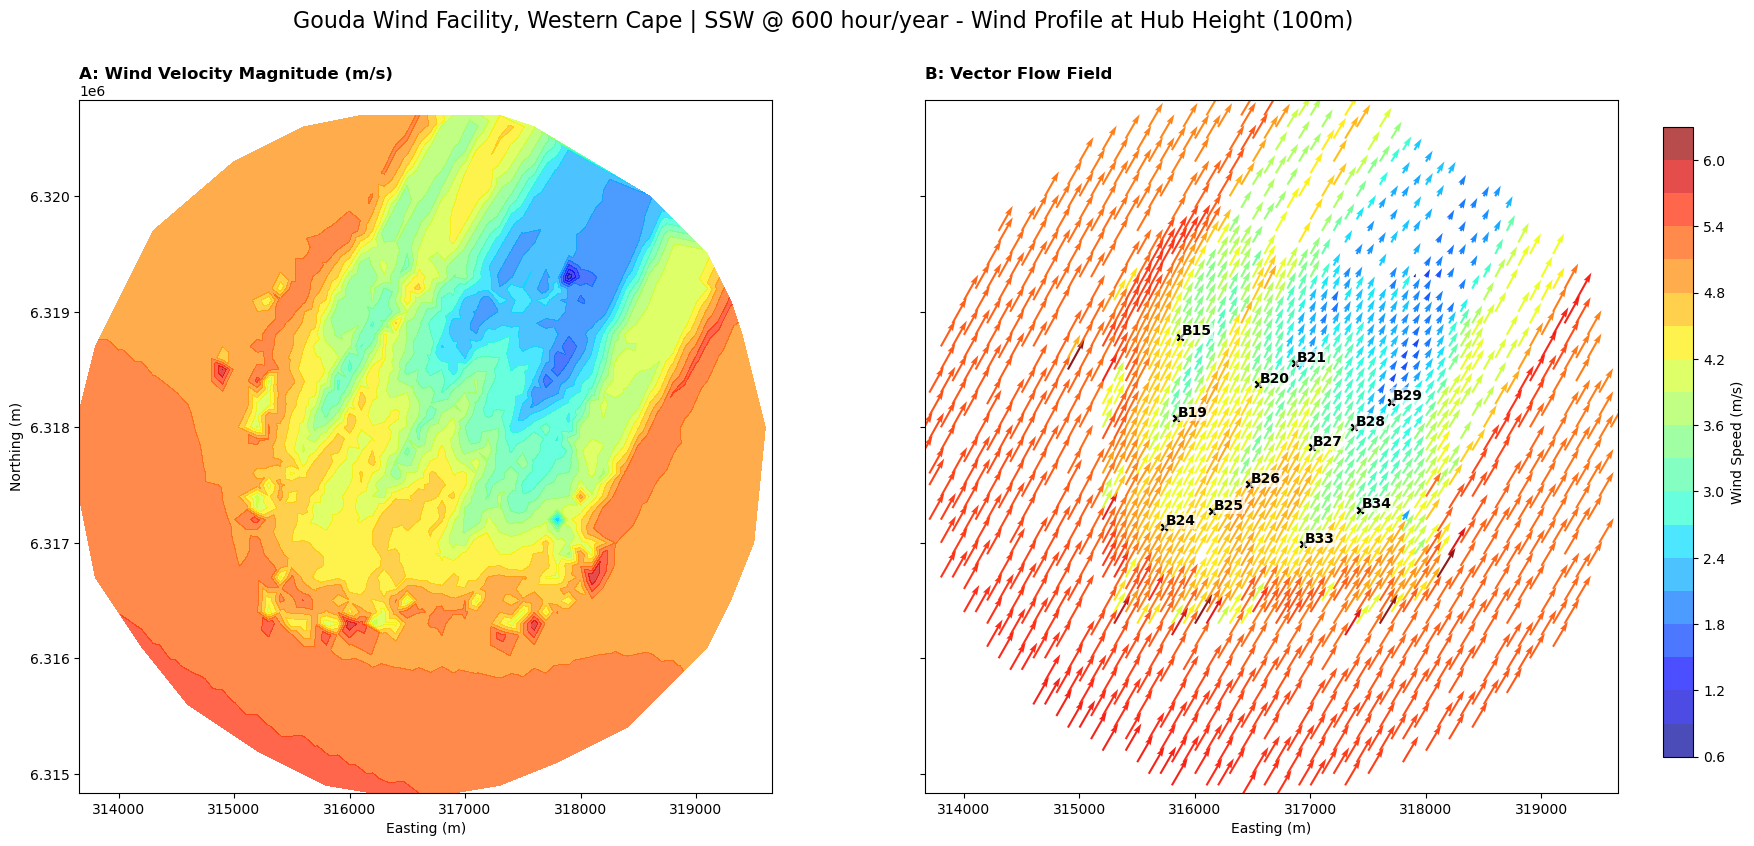

In [13]:
fig, axes =  openSiting.plot_wind_analysis(summer100m, gdf, center_x_utm, center_y_utm, radius=3000, title_suffix="Wind Profile at Hub Height (100m)")

plt.show()

**Power Curve at a specific mast**

In [14]:
def build_slice_dataframe(raw_mesh_df, gdf_masts):
    """
    Groups the raw 3D point data by finding the closest physical turbine mast.
    
    raw_mesh_df: Your dataframe with columns ['X', 'Y', 'Z', 'u_mag']
    gdf_masts: Your GeoDataFrame containing ['mastID', 'local_x', 'local_y']
    """
    matched_rows = []
    gdf_masts['X'] = gdf_masts.geometry.x
    gdf_masts['Y'] = gdf_masts.geometry.y
    
    # Loop through every 3D slice row in your raw dataset
    for _, point in raw_mesh_df.iterrows():
        px, py = point['X'], point['Y']
        
        # Calculate Euclidean distance from this point to all 12 turbine masts
        distances = np.sqrt(
            (gdf_masts['X'] - px)**2 + 
            (gdf_masts['Y'] - py)**2
        )
        
        # Find the index of the nearest physical mast
        closest_idx = distances.idxmin()
        closest_mast = gdf_masts.loc[closest_idx, 'mastID']
        
        # Keep the point and tag it with the correct Mast ID
        point_data = point.to_dict()
        point_data['mastID'] = closest_mast
        matched_rows.append(point_data)
        
    # This output is the 'df_slice' used in the plotting step!
    df_slice = pd.DataFrame(matched_rows)
    return df_slice

df_slice = build_slice_dataframe(summer100m, gdf)
df_slice.head(2)

,X,Y,Z,U,V,u_mag,x_bin,y_bin,mastID
0,319139.600416,6.316167e+06,75.350500,2.055046,3.427506,3.996375,319100.0,6316100.0,34
1,319235.707966,6.316334e+06,75.351675,2.041387,3.412506,3.976488,319200.0,6316300.0,34


In [ ]:
mastID34 = df_slice[df_slice['mastID'] == '34']

In [19]:
#- power curve @ mast

def calculate_Acciona_power(u_hub, rho=1.225):
    """
    Calculates the electric power output (kW) specifically for a Acciona AW-3000.
    Based on manufacturer operational constraints: 4.0 m/s cut-in, 11.7 m/s rated, 25.0 m/s cut-out.
    """
    # Pull constants directly from your turbine specifications
    cut_in = 4.0
    rated_speed = 11.7
    cut_out = 25.0
    rated_power_kw = 3000.0
    swept_area = 7854.0
    
    # 1. Extreme Weather / Sub-operational Conditions
    if u_hub < cut_in or u_hub >= cut_out:
        return 0.0
    
    # 2. Flat Rated Capacity Plateau
    elif rated_speed <= u_hub < cut_out:
        return rated_power_kw
    
    # 3. Cubic Aerodynamic Extraction Zone
    else:
        # Step-wise empirical Cp curve adaptation for calculate_Acciona_power active pitch control
        # This prevents over-estimating yield right before the rated limit.
        if u_hub < 7.0:
            cp = 0.44  # Maximum efficiency in clean, low-to-mid breeze
        elif u_hub < 10.0:
            cp = 0.41  # Active pitch optimization starts turning the blades
        else:
            cp = 0.33  # Bleeding aerodynamic torque to safely approach the 2MW ceiling
            
        power_watts = 0.5 * rho * swept_area * cp * (u_hub ** 3)
        power_kw = power_watts / 1000.0
        
        # Guard rail to clamp mathematical variance to mechanical limits
        return min(power_kw, rated_power_kw)

# Assuming your vertical coordinate column is named 'Z'
hub_height = 100.0

# Find the row closest to 100 for this specific turbine location
hub_row = mastID34.iloc[(mastID34['Z'] - hub_height).abs().argsort()[:1]]
u_hub = hub_row['u_mag'].values[0]

# Run it through your power curve
power_kw = calculate_Acciona_power(u_hub)
power_kw

184.40203613073942

### Relative Power

We look at relative power along the wind direction

In [16]:

# --- 1. SAMPLE INITIAL DATA STRUCTURE ---
# Let's assume 'df_slice' contains your extracted profile data with columns:
# ['mastID', 'X', 'Y', 'Z', 'u_mag']

# Find the mean velocity magnitude for each unique mast across its 70m-130m slice
turbine_summary = []
for mast_id, group in df_slice.groupby('mastID'):
    # Calculate the Rotor Equivalent Wind Speed (REWS) or simple mean
    u_mean = group['u_mag'].mean() 
    # Grab the horizontal coordinate to figure out row order
    x_coord = group['X'].mean() 
    
    turbine_summary.append({
        'mastID': f"B{int(mast_id):02d}", # Formats to 'B01', 'B02' matching your plot style
        'X': x_coord,
        'u_hub': u_mean
    })

df_array = pd.DataFrame(turbine_summary)

# Sort from front to back along the wind direction (West to East / Low X to High X)
df_array = df_array.sort_values(by='X').reset_index(drop=True)
df_array.head(2)

,mastID,X,u_hub
0,B24,315687.786596,4.480624
1,B19,315852.003069,4.067893


In [17]:
# Calculate power using calculate_Acciona_power function
df_array['power_kw'] = df_array['u_hub'].apply(calculate_Acciona_power)

# Define P1 (the leading upstream turbine at index 0 after sorting)
p1_power = df_array.loc[0, 'power_kw']

# Calculate the relative power ratio (Pn / P1)
df_array['Pn_P1'] = df_array['power_kw'] / p1_power
df_array.head(2)

,mastID,X,u_hub,power_kw,Pn_P1
0,B24,315687.786596,4.480624,190.399270,1.00000
1,B19,315852.003069,4.067893,142.481432,0.74833


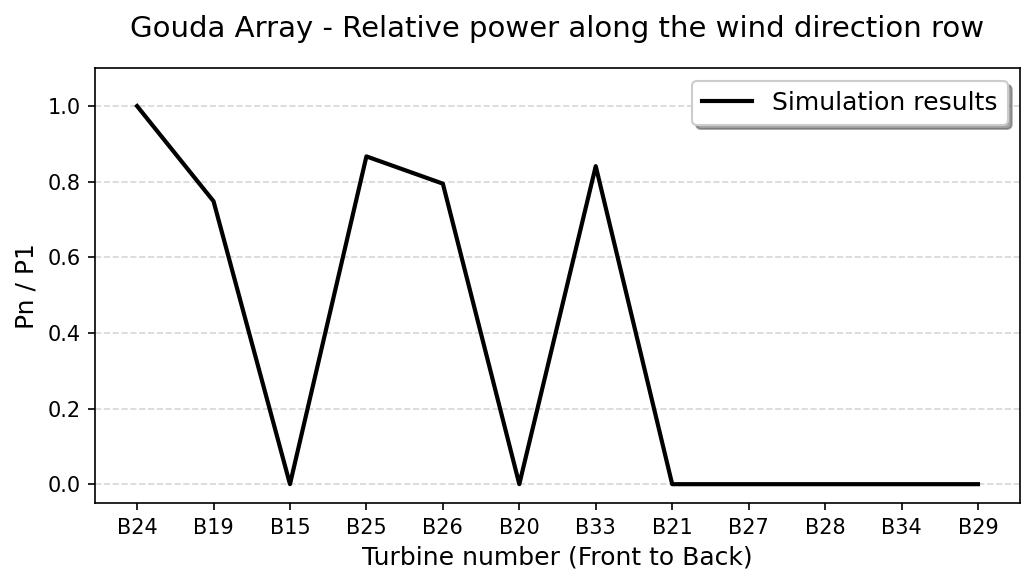

In [108]:
plt.figure(figsize=(7, 4), dpi=150)

# Plot your simulation trend line
plt.plot(df_array['mastID'], df_array['Pn_P1'], 
         color='black', marker='', linestyle='-', linewidth=2, label='Simulation results')

# Add comparison placeholders if you want to plot explicit validation points
plt.scatter(validation_masts, validation_ratios, color='#377eb8', s=60, label='Nygaard et al. 2020')

# Match layout styling
plt.title('Gouda Array - Relative power along the wind direction row', fontsize=14, pad=15)
plt.xlabel('Turbine number (Front to Back)', fontsize=12)
plt.ylabel('Pn / P1', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.1) # Adapts nicely to show the classic ~20-30% dropoff
plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()